[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/Quantlets/Ch_14/ATS_ch14_seminar/ATS_ch14_seminar.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 14: Causal inference for time series

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 14; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- Data: daily market data from EODHD (`data/market` of the ATS repository) and the BNR reference rate; Eurostat HICP and HICP at constant tax rates of the 27 EU countries; the replication data of Abadie, Diamond and Hainmueller (2015) from Harvard Dataverse (CC0); OECD quarterly real GDP (public SDMX API).
- Every estimator is written out with numpy, scipy and statsmodels: synthetic control weights by quadratic programming, CausalImpact on a statsmodels unobserved-components model.

> Quantlet `ATS_ch14_seminar`: student version of the Seminar 14 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5, B7) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, B8, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_14'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# numpy, scipy, statsmodels and scikit-learn are preinstalled in Colab
# !pip install statsmodels scikit-learn

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The engine of Chapter 14, the data helpers and the functions of the solved tasks.

In [ ]:
import io
import sys
import urllib.error
from scipy.special import digamma
from scipy.spatial import cKDTree
SEED = 2026
EUROSTAT = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/'
EU27 = ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
EURO_AREA = ['AT', 'BE', 'CY', 'DE', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']
RO_SC = {'pre_start': '2023-07-01', 'T0': '2025-06-01', 'end': '2026-08-01', 'eval_end': '2026-06-01'}
GERMANY_URL = 'https://dataverse.harvard.edu/api/access/datafile/2457914'
OECD_QNA = 'https://sdmx.oecd.org/public/rest/data/OECD.SDD.NAD,DSD_NAMAIN1@DF_QNA,1.1/Q.Y.{c}.S1..B1GQ._Z._Z._Z.USD_PPP.LR.LA.T0102?startPeriod=1995-Q1&format=csvfile'
BMSS = {'donors': ['AUS', 'AUT', 'BEL', 'CAN', 'FIN', 'FRA', 'DEU', 'HUN', 'ISL', 'IRL', 'ITA', 'JPN', 'KOR', 'LUX', 'NLD', 'NZL', 'NOR', 'PRT', 'SVK', 'ESP', 'SWE', 'CHE', 'USA'], 'published': {'DEU': 0.05, 'HUN': 0.11, 'ISL': 0.01, 'IRL': 0.01, 'ITA': 0.17, 'NZL': 0.14, 'USA': 0.51}, 'pre': ('1995-Q1', '2016-Q2'), 'end': '2018-Q4'}
EVENTS = [('2024-12-06', 'Constitutional Court annuls the presidential election'), ('2025-01-27', 'S&P outlook to negative (announced Friday 24 January)'), ('2025-06-20', 'ECOFIN: no effective action under the EDP'), ('2025-07-07', 'Government assumes responsibility for the fiscal package')]
BTC = {'start': '2023-01-02', 'T0': '2024-01-07', 'end': '2024-06-30', 'anticip': '2023-06-11', 'controls': ('sp500', 'ndx', 'gold', 'eurusd')}
STAG_SLOPES = {6: 0.4, 11: 0.2, 16: 0.05}
PCMCI_NAMES = ['nikkei', 'stoxx50', 'wig20', 'bet', 'sp500', 'eurron']
PCMCI_LABELS = {'nikkei': 'Nikkei', 'stoxx50': 'Euro Stoxx', 'wig20': 'WIG20', 'bet': 'BET', 'sp500': 'S&P 500', 'eurron': 'EUR/RON'}
ADH_SPEC = {1990: ({'prior': range(1971, 1981), 'special': [('industry', range(1971, 1981)), ('schooling', (1970, 1975)), ('invest70', (1980,))], 'ssr': range(1981, 1991)}, {'prior': range(1981, 1991), 'special': [('industry', range(1981, 1991)), ('schooling', (1980, 1985)), ('invest80', (1980,))], 'ssr': range(1960, 1990)}), 1975: ({'prior': range(1960, 1965), 'special': [('industry', (1971,)), ('schooling', (1960, 1965)), ('invest60', (1980,))], 'ssr': range(1965, 1976)}, {'prior': range(1965, 1976), 'special': [('industry', range(1971, 1976)), ('schooling', (1970, 1975)), ('invest70', (1980,))], 'ssr': range(1960, 1976)})}
_MEM = {}
A1 = {'var_w': 1.0, 'var_e': 1.0, 'var_u': 1.0}
A2 = {'phi': 0.8, 'var_eta': 1.0, 'var_e': 0.5, 'var_u': 1.0, 'd_x': 1, 'd_y': 3}
A3 = {'y1': (3.0, 4.0, 5.0), 'a': (2.0, 3.0, 4.0), 'b': (6.0, 7.0, 8.0), 'post': (9.0, 5.0, 10.0), 'y1_out': (9.0, 10.0, 11.0)}
A4 = {'ratios': (12.0, 4.7, 4.1, 3.3, 3.2, 3.1, 2.9, 2.6, 2.2, 1.9), 'J': 26}
A5 = {'rho': 0.5, 'sigma2': 1.0, 'n': 12}
A6 = {'trend': 1.0, 'early': (0.0, 1.0, 3.0), 'late': (0.0, 0.0, 1.0)}
A7 = {'P': 0.02, 's2_level': 0.01, 's2_irr': 0.94, 'n': 25}
A8 = {'Edg': 0.4, 'Ed2': 2.0}
CEE_CONTROLS = ['HU', 'PL', 'CZ', 'BG', 'HR', 'SK']


def datefmt(*axes):
    """Concise date ticks (at most six per axis)."""
    import matplotlib.dates as mdates
    for a in axes:
        loc = mdates.AutoDateLocator(maxticks=6)
        a.xaxis.set_major_locator(loc)
        a.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def get_bytes(url):
    """Download a public file once per session (no key); optional local cache folder in ATS_CACHE."""
    import hashlib
    if url in _MEM:
        return _MEM[url]
    cache = os.environ.get('ATS_CACHE')
    path = os.path.join(cache, hashlib.md5(url.encode()).hexdigest()) if cache else None
    if path and os.path.exists(path):
        _MEM[url] = open(path, 'rb').read()
        return _MEM[url]
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0 (ATS course)'})
    _MEM[url] = urllib.request.urlopen(req, timeout=300).read()
    if path:
        os.makedirs(cache, exist_ok=True)
        open(path, 'wb').write(_MEM[url])
    return _MEM[url]


def eurostat_panel(dataset, key_prefix, geos, start='2015-01'):
    """Monthly Eurostat panel (date x geo) from the SDMX 2.1 API; key_prefix such as 'M.I25.TOTAL.'."""
    url = EUROSTAT + dataset + '/' + key_prefix + '+'.join(geos) + f'?format=SDMX-CSV&startPeriod={start}'
    t = pd.read_csv(io.BytesIO(get_bytes(url)))
    t['date'] = pd.to_datetime(t['TIME_PERIOD'] + '-01')
    return t.pivot_table(index='date', columns='geo', values='OBS_VALUE')[geos]


def hicp_annual(ct=False):
    """Annual HICP inflation (%), monthly, of the 27 EU countries, computed as 100 (ln P_t - ln P_{t-12}) from the
    index 2025 = 100 (Eurostat prc_hicp_minr; with ct=True the HICP at constant tax rates, prc_hicp_ct)."""
    key = 'ct' if ct else 'hicp'
    if key not in _MEM:
        P = eurostat_panel('prc_hicp_ct' if ct else 'prc_hicp_minr', 'M.I25.TOTAL.', EU27, start='2014-01')
        L = np.log(P)
        _MEM[key] = (100 * (L - L.shift(12))).loc['2015-01-01':]
    return _MEM[key]


def hicp_index():
    """HICP index 2025 = 100 of the 27 EU countries (Eurostat prc_hicp_minr)."""
    if 'hicpidx' not in _MEM:
        _MEM['hicpidx'] = eurostat_panel('prc_hicp_minr', 'M.I25.TOTAL.', EU27, start='2014-01')
    return _MEM['hicpidx']


def germany():
    """The panel of Abadie, Diamond and Hainmueller (2015): West Germany and 16 OECD countries, 1960-2003
    (Harvard Dataverse doi:10.7910/DVN/24714, version 2.1, CC0): GDP per capita (PPP, current USD), inflation,
    trade openness, schooling, investment rates, industry share."""
    if 'ger' not in _MEM:
        _MEM['ger'] = pd.read_csv(io.BytesIO(get_bytes(GERMANY_URL)), sep='\t')
    return _MEM['ger']


def oecd_gdp():
    """Quarterly real GDP (chain-linked volumes, PPP USD, seasonally adjusted) of the UK and the 23 donors of
    Born et al. (2019) from the OECD Quarterly National Accounts (public SDMX API), normalised to 1 in 1995."""
    if 'oecd' not in _MEM:
        c = '+'.join(['GBR'] + BMSS['donors'])
        t = pd.read_csv(io.BytesIO(get_bytes(OECD_QNA.format(c=c))))
        P = t.pivot_table(index='TIME_PERIOD', columns='REF_AREA', values='OBS_VALUE')
        P = P[['GBR'] + BMSS['donors']]
        _MEM['oecd'] = P / P.loc['1995-Q1':'1995-Q4'].mean()
    return _MEM['oecd']


def weekly_logrv(names, start='2008-01-01', end=END):
    """Weekly log realised variance: log of the sum of squared daily log returns (in %) within each week
    (Monday-Sunday), each series on its own calendar."""
    out = {}
    for k in names:
        r = log_returns(k, start=start, end=end)
        out[k] = np.log((r ** 2).resample('W-SUN').sum().replace(0, np.nan))
    return pd.DataFrame(out).dropna()


def daily_returns(names, start, end=END):
    """Daily log returns (%) on the common trading days of several markets."""
    return pd.concat([log_returns(k, start=start, end=end) for k in names], axis=1).dropna()


def nw_lags(T):
    """Newey-West (1994) rule of thumb: floor(4 (T/100)^(2/9)) lags."""
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def ols_hac(y, X, lags=None, hac=True):
    """OLS of y on X (X includes the constant); coefficient covariance: Newey-West with Bartlett weights (hac=True)
    or classical. Returns beta, covariance, residuals."""
    y, X = np.asarray(y, float), np.asarray(X, float)
    T, k = X.shape
    XtXi = np.linalg.inv(X.T @ X)
    b = XtXi @ X.T @ y
    e = y - X @ b
    if not hac:
        return b, XtXi * (e @ e) / (T - k), e
    L = nw_lags(T) if lags is None else lags
    u = X * e[:, None]
    S = u.T @ u
    for j in range(1, L + 1):
        G = u[j:].T @ u[:-j]
        S += (1 - j / (L + 1)) * (G + G.T)
    return b, XtXi @ S @ XtXi * T / (T - k), e


def wald(b, V, idx):
    """Wald statistic of b[idx] = 0 and its chi-square p-value (q restrictions); also the F form W/q."""
    bi = b[idx]
    W = float(bi @ np.linalg.solve(V[np.ix_(idx, idx)], bi))
    q = len(idx)
    return {'W': W, 'F': W / q, 'p': float(stats.chi2.sf(W, q)), 'q': q}


def lag_design(cols, p):
    """Rows t = p..T-1 of [1, lags 1..p of every column]; cols: list of 1-d arrays of equal length."""
    T = len(cols[0])
    blocks = [np.ones((T - p, 1))]
    for c in cols:
        c = np.asarray(c, float)
        blocks.append(np.column_stack([c[p - j:T - j] for j in range(1, p + 1)]))
    return np.hstack(blocks)


def granger(y, x, z=None, p=2, hac=True, lags=None):
    """Test of Granger non-causality from x to y (conditional on z if given): regression of y_t on p lags of y, x
    (and z); Wald test that the p lags of x are zero, with HAC (default) or classical covariance."""
    cols = [y, x] + ([] if z is None else [np.asarray(c, float) for c in (z if isinstance(z, (list, tuple)) else [z])])
    X = lag_design(cols, p)
    yy = np.asarray(y, float)[p:]
    b, V, e = ols_hac(yy, X, lags, hac)
    idx = list(range(1 + p, 1 + 2 * p))
    out = wald(b, V, idx)
    # restricted regression (without x): the Gaussian transfer entropy is half the log of the variance ratio
    Xr = np.delete(X, idx, axis=1)
    er = yy - Xr @ np.linalg.lstsq(Xr, yy, rcond=None)[0]
    out['te'] = 0.5 * np.log((er @ er) / (e @ e))
    out['T'] = len(yy)
    return out


def sim_common_driver(T, a=0.9, lag_x=1, lag_y=3, s=1.0, seed=0):
    """A common driver w_t (AR(1)) moves x with delay lag_x and y with delay lag_y; x has no effect on y.
    x_t = w_{t-lag_x} + e_t, y_t = w_{t-lag_y} + u_t."""
    rng = np.random.default_rng(seed)
    n = T + 50 + lag_y
    w = np.zeros(n)
    eps = rng.standard_normal(n)
    for t in range(1, n):
        w[t] = a * w[t - 1] + eps[t]
    x = np.r_[np.zeros(lag_x), w[:-lag_x]] + s * rng.standard_normal(n)
    y = np.r_[np.zeros(lag_y), w[:-lag_y]] + s * rng.standard_normal(n)
    k = 50 + lag_y
    return x[k:], y[k:], w[k:]


def knn_cmi(x, y, z=None, k=5):
    """Conditional mutual information I(X; Y | Z) by the k-nearest-neighbour estimator of Frenzel and Pompe (2007)
    (the Kraskov-Stoegbauer-Grassberger idea), maximum norm, rank-transformed margins. Without z: KSG mutual
    information (algorithm 1). In nats."""
    def col(a):
        a = np.asarray(a, float)
        return a[:, None] if a.ndim == 1 else a

    def rank(a):
        return np.column_stack([stats.rankdata(a[:, j]) / len(a) for j in range(a.shape[1])])
    x, y = rank(col(x)), rank(col(y))
    n = len(x)
    if z is None:
        xy = np.hstack([x, y])
        d = cKDTree(xy).query(xy, k + 1, p=np.inf)[0][:, -1] - 1e-12
        nx = np.array([len(v) - 1 for v in cKDTree(x).query_ball_point(x, d, p=np.inf)])
        ny = np.array([len(v) - 1 for v in cKDTree(y).query_ball_point(y, d, p=np.inf)])
        return float(digamma(k) + digamma(n) - np.mean(digamma(nx + 1) + digamma(ny + 1)))
    z = rank(col(z))
    xyz = np.hstack([x, y, z])
    d = cKDTree(xyz).query(xyz, k + 1, p=np.inf)[0][:, -1] - 1e-12
    xz, yz = np.hstack([x, z]), np.hstack([y, z])
    nxz = np.array([len(v) - 1 for v in cKDTree(xz).query_ball_point(xz, d, p=np.inf)])
    nyz = np.array([len(v) - 1 for v in cKDTree(yz).query_ball_point(yz, d, p=np.inf)])
    nz = np.array([len(v) - 1 for v in cKDTree(z).query_ball_point(z, d, p=np.inf)])
    return float(digamma(k) - np.mean(digamma(nxz + 1) + digamma(nyz + 1) - digamma(nz + 1)))


def transfer_entropy(x, y, lag=1, k=5, B=99, block=20, seed=0):
    """Transfer entropy from x to y with history length 1: TE = I(y_t; x_{t-lag} | y_{t-1}) by the kNN estimator;
    p-value from B block permutations of the source (blocks keep its autocorrelation)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    m = max(lag, 1)
    yt, ylag, xl = y[m:], y[m - 1:-1], x[m - lag:len(x) - lag]
    te = knn_cmi(yt, xl, ylag, k)
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(len(xl) / block))
    null = []
    for _ in range(B):
        starts = rng.integers(0, len(xl) - block, nb)
        xs = np.concatenate([xl[s:s + block] for s in starts])[:len(xl)]
        null.append(knn_cmi(yt, xs, ylag, k))
    null = np.array(null)
    return {'te': te, 'p': float((1 + (null >= te).sum()) / (B + 1)), 'null95': float(np.quantile(null, 0.95))}


def sim_nonlinear_coupling(T, c=0.6, seed=0):
    """x drives y through a symmetric nonlinearity (y_t = 0.4 y_{t-1} + c (x_{t-1}^2 - 1) + u_t): the linear
    Granger regression sees no effect, the transfer entropy does. x is Gaussian AR(1)."""
    rng = np.random.default_rng(seed)
    n = T + 100
    x, y = np.zeros(n), np.zeros(n)
    for t in range(1, n):
        x[t] = 0.5 * x[t - 1] + np.sqrt(0.75) * rng.standard_normal()
        y[t] = 0.4 * y[t - 1] + c * (x[t - 1] ** 2 - 1) + rng.standard_normal()
    return x[100:], y[100:]


def parcorr(data, i, tau, j, cond, T0):
    """Partial correlation of X^i_{t-tau} and X^j_t given the lagged variables in cond = [(k, s), ...] (value of
    X^k_{t-s}); rows t = T0..T-1. Returns (r, p-value) with T - T0 - |cond| - 2 degrees of freedom."""
    T = data.shape[0]
    rows = np.arange(T0, T)
    a, b = data[rows - tau, i], data[rows, j]
    if cond:
        Z = np.column_stack([np.ones(len(rows))] + [data[rows - s, k] for k, s in cond])
        a = a - Z @ np.linalg.lstsq(Z, a, rcond=None)[0]
        b = b - Z @ np.linalg.lstsq(Z, b, rcond=None)[0]
    r = float(np.corrcoef(a, b)[0, 1])
    df = len(rows) - len(cond) - 2
    t = r * np.sqrt(df / max(1e-12, 1 - r ** 2))
    return r, float(2 * stats.t.sf(abs(t), df))


def pcmci(data, tau_max=3, pc_alpha=0.2, alpha=0.01, max_conds=None):
    """PCMCI with partial correlations (Runge et al. 2019, Science Advances), lagged links only.
    Step 1 (PC1): for each X^j, start from all (i, tau), tau = 1..tau_max; at stage p remove every candidate that is
    independent of X^j_t (level pc_alpha) given the p strongest other candidates; stop when no stage-p test is
    possible. Step 2 (MCI): test X^i_{t-tau} -> X^j_t given the parents of X^j_t and the (shifted) parents of
    X^i_{t-tau}. Returns MCI values, p-values (N x N x tau_max+1, index [i, j, tau]) and the PC1 parents."""
    data = np.asarray(data, float)
    data = (data - data.mean(0)) / data.std(0)
    T, N = data.shape
    T0 = 2 * tau_max
    parents = {}
    for j in range(N):
        cand = [(i, tau) for i in range(N) for tau in range(1, tau_max + 1)]
        stat = {c: abs(parcorr(data, c[0], c[1], j, [], T0)[0]) for c in cand}
        cand = [c for c in cand if parcorr(data, c[0], c[1], j, [], T0)[1] <= pc_alpha]
        cand.sort(key=lambda c: -stat[c])
        p = 1
        while len(cand) > p and (max_conds is None or p <= max_conds):
            keep = []
            for c in cand:
                others = [o for o in cand if o != c][:p]
                r, pv = parcorr(data, c[0], c[1], j, others, T0)
                if pv <= pc_alpha:
                    keep.append(c)
                    stat[c] = min(stat[c], abs(r))
            cand = sorted(keep, key=lambda c: -stat[c])
            p += 1
        parents[j] = cand
    val = np.zeros((N, N, tau_max + 1))
    pval = np.ones((N, N, tau_max + 1))
    for j in range(N):
        for i in range(N):
            for tau in range(1, tau_max + 1):
                cond = [c for c in parents[j] if c != (i, tau)]
                cond += [(k, s + tau) for k, s in parents[i] if s + tau <= 2 * tau_max and (k, s + tau) not in cond
                         and (k, s + tau) != (i, tau)]
                val[i, j, tau], pval[i, j, tau] = parcorr(data, i, tau, j, cond, T0)
    return {'val': val, 'pval': pval, 'parents': parents, 'links': (pval <= alpha)}


def full_granger_links(data, tau_max=3, alpha=0.01):
    """Benchmark: lagged links from one VAR(tau_max) regression per target (full conditioning), coefficient t-tests."""
    data = np.asarray(data, float)
    data = (data - data.mean(0)) / data.std(0)
    T, N = data.shape
    X = lag_design([data[:, k] for k in range(N)], tau_max)
    pval = np.ones((N, N, tau_max + 1))
    for j in range(N):
        b, V, _ = ols_hac(data[tau_max:, j], X, hac=False)
        se = np.sqrt(np.diag(V))
        for i in range(N):
            for tau in range(1, tau_max + 1):
                c = 1 + i * tau_max + (tau - 1)
                pval[i, j, tau] = 2 * stats.t.sf(abs(b[c] / se[c]), len(X) - X.shape[1])
    return {'pval': pval, 'links': pval <= alpha}


def corr_links(data, tau_max=3, alpha=0.01):
    """Benchmark: lagged links from pairwise (unconditional) lagged correlations."""
    data = np.asarray(data, float)
    data = (data - data.mean(0)) / data.std(0)
    T, N = data.shape
    pval = np.ones((N, N, tau_max + 1))
    for i in range(N):
        for j in range(N):
            for tau in range(1, tau_max + 1):
                pval[i, j, tau] = parcorr(data, i, tau, j, [], 2 * tau_max)[1]
    return {'pval': pval, 'links': pval <= alpha}


def sim_pcmci_system(T, seed=0, a=0.95, c=0.4, n_extra=0, tau_max=3):
    """A known 6-variable lagged system with strong autocorrelation and a common driver (variable 0):
    0 -> 1 (lag 1), 0 -> 2 (lag 2), 1 -> 3 (lag 1), 2 -> 3 (lag 1), 3 -> 4 (lag 2), 5 independent (AR);
    n_extra further independent AR(1) variables (coefficient a) make the problem high-dimensional.
    Returns data (T x (6 + n_extra)) and the true link array [i, j, tau], tau = 0..tau_max."""
    rng = np.random.default_rng(seed)
    n = T + 200
    N = 6 + n_extra
    X = np.zeros((n, N))
    for t in range(2, n):
        e = rng.standard_normal(6)
        X[t, 0] = a * X[t - 1, 0] + e[0]
        X[t, 1] = 0.7 * X[t - 1, 1] + c * X[t - 1, 0] + e[1]
        X[t, 2] = 0.7 * X[t - 1, 2] + c * X[t - 2, 0] + e[2]
        X[t, 3] = 0.6 * X[t - 1, 3] + c * X[t - 1, 1] - c * X[t - 1, 2] + e[3]
        X[t, 4] = 0.8 * X[t - 1, 4] + c * X[t - 2, 3] + e[4]
        X[t, 5] = a * X[t - 1, 5] + e[5]
        if n_extra:
            X[t, 6:] = a * X[t - 1, 6:] + rng.standard_normal(n_extra)
    true = np.zeros((N, N, tau_max + 1), bool)
    for k in range(6, N):
        true[k, k, 1] = True
    for (i, j, tau) in [(0, 0, 1), (0, 1, 1), (0, 2, 2), (1, 1, 1), (1, 3, 1), (2, 2, 1), (2, 3, 1), (3, 3, 1),
                        (3, 4, 2), (4, 4, 1), (5, 5, 1)]:
        true[i, j, tau] = True
    return X[200:], true


def link_rates(links, true):
    """True positive rate (share of true cross links found) and false positive rate (share of absent cross links
    reported); auto-links (i = j) excluded."""
    N = true.shape[0]
    off = ~np.eye(N, dtype=bool)[:, :, None] & np.ones(true.shape, bool)
    off[:, :, 0] = False
    tp = (links & true & off).sum() / max(1, (true & off).sum())
    fp = (links & ~true & off).sum() / max(1, (~true & off).sum())
    return float(tp), float(fp)


def sim_logistic_pair(T, bxy=0.0, byx=0.32, rx=3.8, ry=3.5, seed=0, forcing=None):
    """Coupled logistic maps of Sugihara et al. (2012, Fig. 1): x_{t+1} = x_t (rx - rx x_t - bxy y_t),
    y_{t+1} = y_t (ry - ry y_t - byx x_t). byx > 0: x drives y. forcing=(F, period): both maps receive the same
    periodic forcing, the case in which CCM can report spurious bidirectional causality."""
    rng = np.random.default_rng(seed)
    x, y = np.empty(T + 200), np.empty(T + 200)
    x[0], y[0] = rng.uniform(0.2, 0.4), rng.uniform(0.2, 0.4)
    for t in range(T + 199):
        fx = fy = 0.0
        if forcing is not None:
            F, per = forcing
            fx = fy = F * np.sin(2 * np.pi * t / per)
        x[t + 1] = x[t] * (rx * (1 + fx) - rx * (1 + fx) * x[t] - bxy * y[t])
        y[t + 1] = y[t] * (ry * (1 + fy) - ry * (1 + fy) * y[t] - byx * x[t])
        x[t + 1], y[t + 1] = np.clip(x[t + 1], 1e-6, 1 - 1e-6), np.clip(y[t + 1], 1e-6, 1 - 1e-6)
    return x[200:], y[200:]


def embed_delay(x, E, tau=1):
    """Delay embedding: rows (x_t, x_{t-tau}, ..., x_{t-(E-1)tau}), t = (E-1)tau..T-1."""
    x = np.asarray(x, float)
    s = (E - 1) * tau
    return np.column_stack([x[s - k * tau:len(x) - k * tau] for k in range(E)])


def cross_map(lib_from, target, E=2, tau=1, L=None, rng=None):
    """Cross-map skill: reconstruct `target` from the shadow manifold of `lib_from` with simplex projection
    (E + 1 nearest neighbours, exponential weights), using a random library of L points; returns the correlation
    between the estimates and the true target. Sugihara et al. (2012): if X drives Y, the manifold of Y
    contains the information on X, so cross-mapping Y -> X has skill that grows with L."""
    M = embed_delay(lib_from, E, tau)
    tgt = np.asarray(target, float)[(E - 1) * tau:]
    n = len(M)
    rng = rng or np.random.default_rng(0)
    idx = np.arange(n) if L is None or L >= n else rng.choice(n, L, replace=False)
    tree = cKDTree(M[idx])
    d, nn = tree.query(M, E + 2)
    est = np.empty(n)
    for t in range(n):
        dd, ii = d[t], idx[nn[t]]
        keep = ii != t
        dd, ii = dd[keep][:E + 1], ii[keep][:E + 1]
        w = np.exp(-dd / max(dd[0], 1e-12))
        est[t] = w @ tgt[ii] / w.sum()
    return float(np.corrcoef(est, tgt)[0, 1])


def ccm_curve(x, y, libs, E=2, reps=20, seed=0):
    """Cross-map skill against library size, both directions, averaged over random libraries.
    'xmap_y_from_x': skill of estimating y from the manifold of x (evidence that y drives x)."""
    rng = np.random.default_rng(seed)
    out = {'L': list(libs), 'y_drives_x': [], 'x_drives_y': []}
    for L in libs:
        out['y_drives_x'].append(float(np.mean([cross_map(x, y, E, 1, L, rng) for _ in range(reps)])))
        out['x_drives_y'].append(float(np.mean([cross_map(y, x, E, 1, L, rng) for _ in range(reps)])))
    return out


def sc_weights(X1, X0, v=None):
    """Synthetic control weights: argmin (X1 - X0 w)' V (X1 - X0 w), w >= 0, sum w = 1 (V = diag(v)).
    X1: k-vector, X0: k x J. Solved by SLSQP from equal weights."""
    X1, X0 = np.asarray(X1, float), np.asarray(X0, float)
    scale = max(np.abs(X0).max(), 1e-12)            # the weights do not depend on a common rescaling
    X1, X0 = X1 / scale, X0 / scale
    k, J = X0.shape
    v = np.ones(k) if v is None else np.asarray(v, float)
    H = X0.T @ (v[:, None] * X0)
    g = X0.T @ (v * X1)
    f = lambda w: 0.5 * w @ H @ w - g @ w
    jac = lambda w: H @ w - g
    r = optimize.minimize(f, np.ones(J) / J, jac=jac, bounds=[(0, 1)] * J,
                          constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1, 'jac': lambda w: np.ones(J)},),
                          method='SLSQP', options={'ftol': 1e-14, 'maxiter': 1000})
    w = np.clip(r.x, 0, None)
    return w / w.sum()


def synth_v(X1, X0, Z1, Z0, starts=4, seed=0):
    """Nested optimisation of Synth (Abadie, Diamond and Hainmueller 2011): predictors scaled by their standard
    deviation across units; V = diag(v), v on the simplex (softmax parametrisation); v minimises the pre-period
    MSPE of the outcomes Z (Z1: T0-vector, Z0: T0 x J). Returns v, w and the loss."""
    X = np.column_stack([X1, X0])
    sd = X.std(axis=1, ddof=1)
    sd[sd == 0] = 1
    X1s, X0s = X1 / sd, X0 / sd[:, None]
    k = len(X1)

    def loss(theta):
        v = np.exp(theta - theta.max())
        v /= v.sum()
        w = sc_weights(X1s, X0s, v)
        return float(np.mean((Z1 - Z0 @ w) ** 2))
    rng = np.random.default_rng(seed)
    best = None
    inits = [np.zeros(k)] + [rng.normal(0, 1.5, k) for _ in range(starts - 1)]
    # the regression-based starting point of Synth: v proportional to the squared OLS coefficients of Z on X
    for th in inits:
        r = optimize.minimize(loss, th, method='Nelder-Mead', options={'maxiter': 3000, 'xatol': 1e-6, 'fatol': 1e-10})
        if best is None or r.fun < best.fun:
            best = r
    v = np.exp(best.x - best.x.max())
    v /= v.sum()
    return v, sc_weights(X1s, X0s, v), float(best.fun), sd


def sc_demeaned(Y1pre, Y0pre):
    """Synthetic control with an intercept (Doudchenko and Imbens 2016; Ferman and Pinto 2021): weights fitted on
    pre-period outcomes after removing each unit's pre-period mean; intercept = difference of the means."""
    w = sc_weights(Y1pre - Y1pre.mean(), Y0pre - Y0pre.mean(0))
    return w, float(Y1pre.mean() - Y0pre.mean(0) @ w)


def ascm_ridge(Y1pre, Y0pre, Y0post, w, lam):
    """Ridge-augmented synthetic control (Ben-Michael, Feller and Rothstein 2021, eq. 7): the synthetic control
    plus a ridge correction for the remaining pre-period imbalance,
    Y0hat_t = sum_j w_j Y_jt + (Y1pre - Y0pre w)' eta_t, eta_t = ridge coefficients of Y_jt on Y_j,pre across donors
    (centred). Y0pre: T0 x J, Y0post: T1 x J. Returns the counterfactual path and the augmented weights."""
    Xc = Y0pre.T - Y0pre.T.mean(0)                         # J x T0, donors as observations
    G = Xc @ Xc.T
    J = Xc.shape[0]
    # augmented weights: w_aug = w + Xc (Xc'Xc + lam I)^-1 (Y1pre - Y0pre w)
    imb = Y1pre - Y0pre @ w
    w_aug = w + Xc @ np.linalg.solve(Xc.T @ Xc + lam * np.eye(Xc.shape[1]), imb)
    return Y0post @ w_aug, w_aug, G.trace() / J


def ascm_lambda(Y1pre, Y0pre, grid, holdout=6):
    """Choice of the ridge penalty by holding out the last pre-periods: fit on the first T0 - holdout periods,
    predict the held-out ones, keep the penalty with the smallest MSE."""
    best, mse = None, []
    a, b = Y0pre[:-holdout], Y0pre[-holdout:]
    for lam in grid:
        w = sc_weights(Y1pre[:-holdout], a)
        f, _, _ = ascm_ridge(Y1pre[:-holdout], a, b, w, lam)
        m = float(np.mean((Y1pre[-holdout:] - f) ** 2))
        mse.append(m)
        if best is None or m < best[1]:
            best = (lam, m)
    return best[0], mse


def sdid(Y, n_treated_last, T0):
    """Synthetic difference in differences (Arkhangelsky et al. 2021, Algorithm 1) for one treated unit (the last
    row of Y, units x periods) treated after period T0. Unit weights: penalised SC with intercept, zeta^2 =
    (N_tr T_post)^(1/2) sigma^2, sigma = sd of first differences of the control outcomes before treatment; time
    weights: SC of the post-period mean on the pre-periods with intercept (tiny ridge). Returns the average effect,
    the per-period effects, omega and lambda."""
    Y = np.asarray(Y, float)
    N, T = Y.shape
    Nco = N - n_treated_last
    Yco, Ytr = Y[:Nco], Y[Nco:].mean(0)
    T1 = T - T0
    sig = np.std(np.diff(Yco[:, :T0], axis=1), ddof=1)
    zeta = (n_treated_last * T1) ** 0.25 * sig

    def simplex_ls(A, b, pen):
        k = A.shape[1]
        # intercept handled by demeaning across the rows of A and b
        sc_ = max(np.abs(A).max(), 1e-12)
        Ac, bc = (A - A.mean(0)) / sc_, (b - b.mean()) / sc_
        pen = pen / sc_ ** 2
        H = Ac.T @ Ac + pen * np.eye(k)
        g = Ac.T @ bc
        r = optimize.minimize(lambda x: 0.5 * x @ H @ x - g @ x, np.ones(k) / k, jac=lambda x: H @ x - g,
                              bounds=[(0, 1)] * k, method='SLSQP',
                              constraints=({'type': 'eq', 'fun': lambda x: x.sum() - 1},),
                              options={'ftol': 1e-14, 'maxiter': 1000})
        x = np.clip(r.x, 0, None)
        return x / x.sum()
    omega = simplex_ls(Yco[:, :T0].T, Ytr[:T0], zeta ** 2 * T0)
    lam = simplex_ls(Yco[:, :T0], Yco[:, T0:].mean(1), 1e-6 * sig ** 2 * Nco)
    base_tr = Ytr[:T0] @ lam
    base_co = Yco[:, :T0] @ lam
    per = (Ytr[T0:] - base_tr) - omega @ (Yco[:, T0:] - base_co[:, None])
    return {'tau': float(per.mean()), 'per': per, 'omega': omega, 'lambda': lam, 'zeta': float(zeta)}


def sdid_placebo_se(Y, T0, reps=None):
    """Placebo standard error of SDID (Arkhangelsky et al. 2021, Algorithm 4) with one treated unit: each control
    in turn plays the treated unit among the other controls; se = sd of the placebo average effects."""
    Yco = np.asarray(Y, float)[:-1]
    taus = []
    for j in range(len(Yco)):
        Yp = np.vstack([np.delete(Yco, j, axis=0), Yco[j]])
        taus.append(sdid(Yp, 1, T0)['tau'])
    return float(np.std(taus, ddof=1)), np.array(taus)


def placebo_ratios(Y, T0, method='sc', **kw):
    """In-space placebo test (Abadie, Diamond and Hainmueller 2010): each unit in turn is treated as the treated
    one with all the others as donors; ratio of post- to pre-period RMSPE. Y: units x periods, the treated unit in
    the last row. Returns gaps (units x periods), ratios and the permutation p-value of the treated unit."""
    Y = np.asarray(Y, float)
    N, T = Y.shape
    gaps, ratios = np.zeros((N, T)), np.zeros(N)
    for i in range(N):
        y1, Y0 = Y[i], np.delete(Y, i, axis=0).T
        if method == 'sc':
            w = sc_weights(y1[:T0], Y0[:T0])
            fit = Y0 @ w
        else:
            w, c = sc_demeaned(y1[:T0], Y0[:T0])
            fit = Y0 @ w + c
        gaps[i] = y1 - fit
        ratios[i] = np.sqrt(np.mean(gaps[i, T0:] ** 2)) / np.sqrt(np.mean(gaps[i, :T0] ** 2))
    p = float((ratios >= ratios[-1]).sum() / N)
    return gaps, ratios, p


def sim_staggered(n_per=60, T=20, cohorts=(6, 11, 16), seed=0, slope=0.25):
    """Panel with staggered adoption: cohorts treated from the given periods, a never-treated group; the effect
    grows with exposure (slope per period; a dict {cohort: slope} makes it heterogeneous across cohorts), unit and
    time fixed effects, i.i.d. noise. Returns a long DataFrame."""
    rng = np.random.default_rng(seed)
    rows = []
    groups = list(cohorts) + [0]
    for g in groups:
        for i in range(n_per):
            a = rng.normal()
            for t in range(1, T + 1):
                e = max(0, t - g + 1) if g else 0
                sl = slope.get(g, 0.0) if isinstance(slope, dict) else slope
                y = a + 0.1 * t + sl * e + rng.normal(scale=0.5)
                rows.append((f'{g}_{i}', g, t, y, int(g > 0 and t >= g)))
    return pd.DataFrame(rows, columns=['id', 'g', 't', 'y', 'd'])


def twfe_event(df, K=8):
    """Two-way fixed effects event-study regression with relative-time dummies -K..K (reference -1, endpoints
    binned), never-treated units included; within transformation by two-way demeaning (balanced panel)."""
    d = df.copy()
    d['rel'] = np.where(d['g'] > 0, d['t'] - d['g'], -999)
    ks = [k for k in range(-K, K + 1) if k != -1]
    for k in ks:
        if k == -K:
            d[f'e{k}'] = ((d['rel'] <= k) & (d['rel'] > -999)).astype(float)
        elif k == K:
            d[f'e{k}'] = (d['rel'] >= k).astype(float)
        else:
            d[f'e{k}'] = (d['rel'] == k).astype(float)
    cols = ['y'] + [f'e{k}' for k in ks]
    W = d[cols] - d.groupby('id')[cols].transform('mean') - d.groupby('t')[cols].transform('mean') + d[cols].mean()
    b = np.linalg.lstsq(W[cols[1:]].values, W['y'].values, rcond=None)[0]
    static = np.linalg.lstsq((d['d'] - d.groupby('id')['d'].transform('mean') - d.groupby('t')['d'].transform('mean')
                              + d['d'].mean()).values[:, None], W['y'].values, rcond=None)[0][0]
    return dict(zip(ks, b)), float(static)


def cs_att(df, K=8):
    """Callaway and Sant'Anna (2021) group-time effects with never-treated controls (no covariates):
    ATT(g, t) = [E(Y_t - Y_{g-1} | G = g) - E(Y_t - Y_{g-1} | never treated)]; event-study aggregation with
    cohort-size weights; and the overall average of the post-treatment ATT(g, t)."""
    P = df.pivot_table(index='id', columns='t', values='y')
    g = df.groupby('id')['g'].first()
    never = P[g == 0]
    att = {}
    for gg in sorted(set(g) - {0}):
        grp = P[g == gg]
        for t in P.columns:
            base = gg - 1 if t >= gg else t - 1
            if base < P.columns.min():
                continue
            att[(gg, t)] = ((grp[t] - grp[base]).mean() - (never[t] - never[base]).mean(), len(grp))
    ev = {}
    for k in range(-K, K + 1):
        cells = [(v, n) for (gg, t), (v, n) in att.items() if t - gg == k]
        if cells:
            ev[k] = sum(v * n for v, n in cells) / sum(n for _, n in cells)
    post = [(v, n) for (gg, t), (v, n) in att.items() if t >= gg]
    return ev, float(sum(v * n for v, n in post) / sum(n for _, n in post))


def causal_impact(y, X, pre_end, level='llevel', draws=1000, seed=0, alpha=0.05):
    """CausalImpact-type analysis (Brodersen et al. 2015) with a state space model fitted by maximum likelihood on
    the pre-period (statsmodels UnobservedComponents): y_t = mu_t + x_t'beta + e_t, mu_t a local level (random walk).
    Counterfactual post-period paths are simulated from the model given the observed controls, with parameter
    uncertainty (parameters drawn from their asymptotic normal distribution) and state uncertainty (simulation
    from the filtered state at the end of the pre-period). y, X: pandas objects on the same index.
    Returns pointwise and cumulative effects with (1 - alpha) intervals and the posterior tail probability."""
    import statsmodels.api as sm
    y = pd.Series(y, dtype=float)
    X = pd.DataFrame(X).astype(float)
    pre = y.index <= pd.Timestamp(pre_end)
    mod = sm.tsa.UnobservedComponents(y[pre], level=level, exog=X[pre] if X.shape[1] else None)
    res = mod.fit(disp=False, maxiter=2000)
    rng = np.random.default_rng(seed)
    npost = int((~pre).sum())
    Xpost = X[~pre].values if X.shape[1] else None
    cov = res.cov_params().values
    paths = np.empty((draws, npost))
    names = list(res.params.index)
    for d in range(draws):
        th = res.params.values.copy()
        try:
            th = rng.multivariate_normal(res.params.values, cov)
        except Exception:
            pass
        for k, nm in enumerate(names):                       # variances must stay positive
            if nm.startswith('sigma2'):
                th[k] = abs(th[k])
        rd = mod.smooth(th)
        sim = rd.simulate(npost, anchor='end', exog=Xpost, random_state=rng)
        paths[d] = np.asarray(sim).ravel()
    ypost = y[~pre].values
    point = ypost - paths.mean(0)
    lo, hi = np.quantile(ypost - paths, [alpha / 2, 1 - alpha / 2], axis=0)
    cum = np.cumsum(ypost - paths, axis=1)
    out = {'pred': paths.mean(0), 'pred_lo': np.quantile(paths, alpha / 2, axis=0),
           'pred_hi': np.quantile(paths, 1 - alpha / 2, axis=0), 'effect': point, 'lo': lo, 'hi': hi,
           'cum': cum.mean(0), 'cum_lo': np.quantile(cum, alpha / 2, axis=0), 'cum_hi': np.quantile(cum, 1 - alpha / 2, axis=0),
           'avg': float((ypost - paths).mean()), 'avg_lo': float(np.quantile((ypost - paths).mean(1), alpha / 2)),
           'avg_hi': float(np.quantile((ypost - paths).mean(1), 1 - alpha / 2)),
           'p': float(min((paths.mean(1) >= ypost.mean()).mean(), (paths.mean(1) <= ypost.mean()).mean())),
           'params': res.params.to_dict(), 'fitted_pre': (y[pre] - res.resid).values, 'index_post': y.index[~pre]}
    return out


def dml_plr(y, d, X, learner, K=5, gap=0):
    """Partially linear model y = theta d + g(X) + u, d = m(X) + v (Chernozhukov et al. 2018): cross-fitted
    residuals from K contiguous blocks (training excludes `gap` observations on each side of the held-out block);
    theta = sum(v_hat y_hat) / sum(v_hat d_hat); HAC standard error of the orthogonal score."""
    y, d, X = np.asarray(y, float), np.asarray(d, float), np.asarray(X, float)
    n = len(y)
    ry, rd = np.empty(n), np.empty(n)
    edges = np.linspace(0, n, K + 1).astype(int)
    for k in range(K):
        a, b = edges[k], edges[k + 1]
        tr = np.r_[0:max(0, a - gap), min(n, b + gap):n]
        my = learner().fit(X[tr], y[tr])
        md = learner().fit(X[tr], d[tr])
        ry[a:b] = y[a:b] - my.predict(X[a:b])
        rd[a:b] = d[a:b] - md.predict(X[a:b])
    theta = float(rd @ ry / (rd @ rd))
    psi = (ry - theta * rd) * rd
    L = nw_lags(n)
    v = psi @ psi / n
    for j in range(1, L + 1):
        v += 2 * (1 - j / (L + 1)) * (psi[j:] @ psi[:-j]) / n
    se = float(np.sqrt(v / n) / np.mean(rd ** 2))
    return {'theta': theta, 'se': se}


def sim_dml(T, theta=0.5, seed=0):
    """A dependent-data design for DML: X_t is a VAR(1) of 10 variables; the treatment d_t and the outcome y_t
    depend on X_t through nonlinear functions; AR(1) errors."""
    rng = np.random.default_rng(seed)
    p = 10
    X = np.zeros((T + 100, p))
    for t in range(1, T + 100):
        X[t] = 0.7 * X[t - 1] + rng.standard_normal(p)
    X = X[100:]
    v, u = np.zeros(T), np.zeros(T)
    for t in range(1, T):
        v[t] = 0.5 * v[t - 1] + rng.standard_normal()
        u[t] = 0.5 * u[t - 1] + rng.standard_normal()
    m = np.tanh(X[:, 0]) + 0.5 * X[:, 1] ** 2 / 2
    g = np.sin(X[:, 0]) + 0.5 * X[:, 1] ** 2 + 0.5 * np.abs(X[:, 2])
    d = m + v
    y = theta * d + g + u
    return y, d, X


def adh_matrices(d, unit, controls, pred_years, special, z_years):
    """Synth's dataprep: predictors gdp, trade, infrate averaged over pred_years (missing values ignored), special
    predictors [(var, years)] averaged over their years; outcomes Z (gdp) over z_years. Returns X1, X0, Z1, Z0."""
    def col(u):
        g = d[d['index'] == u].set_index('year')
        v = [g.loc[list(pred_years), c].mean() for c in ('gdp', 'trade', 'infrate')]
        v += [g.loc[list(yrs), c].mean() for c, yrs in special]
        return np.array(v, float)
    X1 = col(unit)
    X0 = np.column_stack([col(u) for u in controls])
    Y = d.pivot_table(index='year', columns='index', values='gdp')
    return X1, X0, Y.loc[list(z_years), unit].values, Y.loc[list(z_years), controls].values


def adh_fit(d, unit, controls, t_treat=1990, starts=3):
    """ADH (2015, Section 4 and rep.r): V chosen by cross-validation (training predictors, validation outcomes),
    then the weights from the main predictors with that V (Synth's custom.v)."""
    tr, mn = ADH_SPEC[t_treat]
    X1, X0, Z1, Z0 = adh_matrices(d, unit, controls, tr['prior'], tr['special'], tr['ssr'])
    v, _, _, _ = synth_v(X1, X0, Z1, Z0, starts=starts, seed=SEED)
    X1m, X0m, _, _ = adh_matrices(d, unit, controls, mn['prior'], mn['special'], mn['ssr'])
    sd = np.column_stack([X1m, X0m]).std(axis=1, ddof=1)
    w = sc_weights(X1m / sd, X0m / sd[:, None], v)
    return w, v, X1m, X0m


def bmss_fit(U, unit, donors, pre_end):
    """Outcome-only doppelganger: weights matching real GDP (1995 = 1) over 1995Q1 to pre_end."""
    pre = U.loc[:pre_end]
    return sc_weights(pre[unit].values, pre[donors].values)


def its_design(idx, crisis=('2021-07-01', '2023-06-01')):
    """Design of the pre-intervention model of monthly inflation: 12 month dummies (no constant) and a step for the
    2021-2023 inflation surge."""
    M = np.column_stack([(idx.month == m).astype(float) for m in range(1, 13)])
    surge = ((idx >= crisis[0]) & (idx <= crisis[1])).astype(float)
    return np.column_stack([M, surge])


def ro_panel(ct=False, pre_start=RO_SC['pre_start'], end=RO_SC['end'], donors=None):
    """Units x periods matrix of annual HICP inflation, donors first, Romania last."""
    A = hicp_annual(ct).loc[pre_start:end]
    donors = donors or [c for c in EU27 if c != 'RO']
    A = A[donors + ['RO']].dropna(axis=0)
    return A, donors


def a1_common_driver():
    """x_t = w_{t-1} + e_t, y_t = w_{t-2} + u_t, w, e, u independent white noise: regression of y_t on x_{t-1}."""
    vw, ve, vu = A1['var_w'], A1['var_e'], A1['var_u']
    b = vw / (vw + ve)
    s_full = vw + vu - vw ** 2 / (vw + ve)
    s_restr = vw + vu
    F = np.log(s_restr / s_full)
    return dict(b=b, s_full=s_full, s_restr=s_restr, F=F, te=F / 2)


def a3_sc_by_hand():
    """Two donors: w minimises sum_t (y1 - w a - (1 - w) b)^2 on [0, 1]; post-period effect; the treated unit
    outside the hull; the demeaned version."""
    y1, a, b = (np.array(A3[k]) for k in ('y1', 'a', 'b'))
    d = a - b
    w = float(np.clip((y1 - b) @ d / (d @ d), 0, 1))
    y_post, a_post, b_post = A3['post']
    synth = w * a_post + (1 - w) * b_post
    yo = np.array(A3['y1_out'])
    wo = float(np.clip((yo - b) @ d / (d @ d), 0, 1))
    res_o = yo - (wo * a + (1 - wo) * b)
    return dict(w=w, synth=synth, effect=y_post - synth, w_out=wo, resid_out=res_o.tolist(),
                rmspe_out=float(np.sqrt(np.mean(res_o ** 2))))


def a5_ar1_sum():
    """Variance of the sum of n AR(1) errors (innovation variance sigma2): exact, i.i.d. approximation and the
    long-run variance approximation n Omega, Omega = sigma2 / (1 - rho)^2."""
    rho, s2, n = A5['rho'], A5['sigma2'], A5['n']
    g0 = s2 / (1 - rho ** 2)
    exact = g0 * (n + 2 * sum((n - k) * rho ** k for k in range(1, n)))
    return dict(g0=g0, iid=n * g0, exact=exact, lrv=n * s2 / (1 - rho) ** 2, ratio=float(np.sqrt(exact / (n * g0))))


def a7_local_level():
    """Local level counterfactual: Var(mu_{T+h}) = P + h s2_level; Var of the cumulative sum over n steps:
    n^2 P + s2_level sum_{k=1}^n k^2 + n s2_irr."""
    P, sl, se, n = A7['P'], A7['s2_level'], A7['s2_irr'], A7['n']
    v1 = P + sl + se
    vn = P + n * sl + se
    vcum = n ** 2 * P + sl * sum(k ** 2 for k in range(1, n + 1)) + n * se
    return dict(v1=v1, vn=vn, vcum=vcum, sd_avg=float(np.sqrt(vcum) / n), half_width=float(1.96 * np.sqrt(vcum) / n))


def b1_granger_markets(p=2):
    out = {}
    for start, end, lab in (('2015-01-01', '2026-09-18', 'full'), ('2020-01-01', '2026-09-18', 'since2020')):
        R = daily_returns(['sp500', 'dax', 'bet'], start, end)
        sp, dx, bt = R['sp500'].values, R['dax'].values, R['bet'].values
        out[lab] = {'T': int(len(R)),
                    'sp_bet_hac': granger(bt, sp, p=p), 'sp_bet_cl': granger(bt, sp, p=p, hac=False),
                    'bet_sp_hac': granger(sp, bt, p=p), 'sp_bet_dax': granger(bt, sp, z=dx, p=p),
                    'dax_bet': granger(bt, dx, p=p)}
    return out


def b3_germany_outcome_only(save_it=True):
    """SC on all pre-1990 outcomes (no covariates) against the ADH cross-validated SC; in-space placebos of the
    outcome-only SC."""
    d = germany()
    names = d.groupby('index')['country'].first()
    Y = d.pivot_table(index='year', columns='index', values='gdp')
    yrs = Y.index.values
    pre = yrs < 1990
    ctrl = [u for u in Y.columns if u != 7]
    w = sc_weights(Y.loc[pre, 7].values, Y.loc[pre, ctrl].values)
    s_oo = Y[ctrl].values @ w
    wa, _, _, _ = adh_fit(d, 7, ctrl)
    s_adh = Y[ctrl].values @ wa
    Ymat = Y[ctrl + [7]].values.T
    gaps, ratios, p = placebo_ratios(Ymat, int(pre.sum()))
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
    ax[0].plot(yrs, Y[7].values - s_oo, color=st.IDAred, lw=2, label='gap, outcome-only SC')
    ax[0].plot(yrs, Y[7].values - s_adh, color=st.MainBlue, lw=2, ls='--', label='gap, ADH (2015) SC')
    ax[0].axhline(0, color=st.DarkText, lw=0.6)
    ax[0].axvline(1990, color=st.Amber, ls=':', lw=1)
    ax[0].set_ylabel('USD per capita')
    st.legend_outside_bottom(ax[0], ncol=2, y=-0.16)
    for i in range(len(ctrl)):
        ax[1].plot(yrs, gaps[i], color=st.Teal, lw=0.7, alpha=0.7, label='placebo countries' if i == 0 else '_')
    ax[1].plot(yrs, gaps[-1], color=st.IDAred, lw=2, label='West Germany')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    ax[1].axvline(1990, color=st.Amber, ls=':', lw=1)
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.16)
    plt.tight_layout()
    save('ch14_sem_b3', save_it)
    post = yrs >= 1990
    return {'w': {names[u]: float(x) for u, x in zip(ctrl, w) if x > 0.005},
            'avg_oo': float(np.mean(Y[7].values[post] - s_oo[post])), 'avg_adh': float(np.mean(Y[7].values[post] - s_adh[post])),
            'rmspe_oo': float(np.sqrt(np.mean((Y[7].values[pre] - s_oo[pre]) ** 2))),
            'rmspe_adh': float(np.sqrt(np.mean((Y[7].values[pre] - s_adh[pre]) ** 2))),
            'p': p, 'rank': int((ratios >= ratios[-1]).sum()), 'n': len(ratios)}


def b5_impact_romania(save_it=True, draws=500):
    """CausalImpact-type analysis of Romanian annual HICP inflation with six CEE countries as controls, pre-period
    January 2017 - June 2025, effects July 2025 - June 2026."""
    A = hicp_annual().loc['2017-01-01':RO_SC['eval_end']]
    ci = causal_impact(A['RO'], A[CEE_CONTROLS], RO_SC['T0'], draws=draws, seed=SEED)
    post = A.index > RO_SC['T0']
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
    sel = A.index >= '2023-01-01'
    ax[0].plot(A.index[sel], A['RO'][sel], color=st.IDAred, lw=2, label='Romania')
    ax[0].plot(A.index[post], ci['pred'], color=st.MainBlue, lw=2, ls='--', label='counterfactual')
    ax[0].fill_between(A.index[post], ci['pred_lo'], ci['pred_hi'], color=st.MainBlue, alpha=0.15, label='95% interval')
    ax[0].set_ylabel('% y/y')
    st.legend_outside_bottom(ax[0], ncol=3, y=-0.16)
    ax[1].plot(A.index[post], ci['effect'], color=st.IDAred, lw=2, label='pointwise effect')
    ax[1].fill_between(A.index[post], ci['lo'], ci['hi'], color=st.IDAred, alpha=0.15, label='95% interval')
    ax[1].axhline(0, color=st.DarkText, lw=0.6)
    st.legend_outside_bottom(ax[1], ncol=2, y=-0.16)
    datefmt(*ax)
    plt.tight_layout()
    save('ch14_sem_b5', save_it)
    return {'avg': ci['avg'], 'lo': ci['avg_lo'], 'hi': ci['avg_hi'], 'p': ci['p'],
            'beta': {k.replace('beta.', ''): v for k, v in ci['params'].items() if k.startswith('beta')},
            's2l': ci['params']['sigma2.level'], 's2e': ci['params']['sigma2.irregular'], 'n_pre': int((~post).sum())}


def b7_its_placebo(save_it=True):
    """ITS for Romanian monthly inflation (lecture design) and the same design with a fictitious intervention in
    July 2024 (fitted on data to June 2024, effects July 2024 - June 2025)."""
    P = hicp_index()['RO']
    m = (100 * np.log(P).diff()).loc['2015-01-01':'2026-06-01'].dropna()
    out = {}
    for lab, T0, end in (('true', '2025-06-01', '2026-06-01'), ('placebo', '2024-06-01', '2025-06-01')):
        mm = m.loc[:end]
        pre = mm.index <= T0
        X = its_design(mm.index)
        r = {}
        for hac in (False, True):
            b, V, e = ols_hac(mm.values[pre], X[pre], hac=hac)
            eff = mm.values[~pre] - X[~pre] @ b
            a = X[~pre].sum(0)
            s2 = float(e @ e / (pre.sum() - X.shape[1]))
            lrv = s2
            if hac:
                L = nw_lags(int(pre.sum()))
                for j in range(1, L + 1):
                    lrv += 2 * (1 - j / (L + 1)) * float(e[j:] @ e[:-j]) / (pre.sum() - X.shape[1])
            se = float(np.sqrt(len(eff) * lrv + a @ V @ a))
            r['hac' if hac else 'iid'] = {'cum': float(eff.sum()), 'se': se, 'z': float(eff.sum() / se)}
        r['eff'] = eff.tolist()
        r['idx'] = [str(d.date()) for d in mm.index[~pre]]
        out[lab] = r
    fig, ax = plt.subplots(figsize=(10, 3.6))
    for lab, c in (('placebo', st.MainBlue), ('true', st.IDAred)):
        x = pd.to_datetime(out[lab]['idx'])
        ax.plot(x, np.cumsum(out[lab]['eff']), 'o-', color=c, label=f'cumulative effect, {lab} date')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_ylabel('percentage points (log)')
    datefmt(ax)
    st.legend_outside_bottom(ax, ncol=2, y=-0.16)
    save('ch14_sem_b7', save_it)
    return out

# Part A: derivations and computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: Granger causality from a common driver

**Context.** w, e, u independent white noise with variance 1; x_t = w_{t-1} + e_t, y_t = w_{t-2} + u_t.

1. The coefficient of y_t on x_{t-1} and the two residual variances.
2. The Geweke measure and the Gaussian transfer entropy.
3. The effect on y of an intervention on x.

**Report:** three numbers; two numbers; one sentence.

In [8]:
# Solution
print(a1_common_driver())

{'b': 0.5, 's_full': 1.5, 's_restr': 2.0, 'F': np.float64(0.28768207245178085), 'te': np.float64(0.14384103622589042)}


**Interpretation of the result.** x predicts y because it reads the common driver early; an intervention on x has no effect.

## A2 [Proposed]: a persistent common driver

**Context.** w_t = 0.8 w_{t-1} + eta_t; x_t = w_{t-1} + e_t with Var(e) = 0.5; y_t = w_{t-3} + u_t. Model: A1.

1. gamma_0 and Cov(y_t, x_{t-1}).
2. b, the residual variance and F for the regression of y_t on x_{t-1} only.
3. Why persistence strengthens the spurious link.

**Report:** two numbers; three numbers; one sentence.

In [ ]:
# Your code here


## A3 [Solved]: synthetic control weights by hand

**Context.** Treated (3, 4, 5), donor A (2, 3, 4), donor B (6, 7, 8); post: treated 9, A 5, B 10.

1. The weight w on A.
2. The synthetic post value and the effect.
3. A treated unit (9, 10, 11): the convex-hull problem and the intercept.

**Report:** one number; two numbers; two numbers and one sentence.

In [10]:
# Solution
print(a3_sc_by_hand())

{'w': 0.75, 'synth': 6.25, 'effect': 2.75, 'w_out': 0.0, 'resid_out': [3.0, 3.0, 3.0], 'rmspe_out': 3.0}


**Interpretation of the result.** Outside the hull no convex combination fits; an intercept restores the fit.

## A4 [Proposed]: placebo p-values

**Context.** Ratios 12.0, 4.7, 4.1, 3.3, 3.2, 3.1, 2.9, 2.6, 2.2, 1.9 (treated first). Model: A3.

1. The p-value of the treated unit and of the second unit.
2. The smallest p-value with 26 donors.
3. Why the ratio.

**Report:** two numbers; one number; one sentence.

In [ ]:
# Your code here


## A5 [Solved]: the variance of a cumulative effect

**Context.** AR(1) errors, rho = 0.5, sigma^2 = 1, n = 12.

1. gamma_0 and the i.i.d. variance of the sum.
2. The exact variance and n Omega.
3. The factor by which i.i.d. standard errors are too small.

**Report:** two numbers; two numbers; one number.

In [12]:
# Solution
print(a5_ar1_sum())

{'g0': 1.3333333333333333, 'iid': 16.0, 'exact': 42.66796875, 'lrv': 48.0, 'ratio': 1.633018079163547}


**Interpretation of the result.** Moderate persistence makes nominal 95% i.i.d. intervals much narrower than they should be.

## A6 [Proposed]: the forbidden comparison

**Context.** Two cohorts, three periods, common trend +1; early effects 1 and 3 from period 1; late effect 1 in period 2. Model: A5.

1. The two outcome paths.
2. The clean and the forbidden 2x2 DiD.
3. Why the second is forbidden.

**Report:** two paths; two numbers; one sentence.

In [ ]:
# Your code here


## A7 [Solved]: intervals of a local level counterfactual

**Context.** sigma^2_eta = 0.01, sigma^2_eps = 0.94, P = 0.02, n = 25.

1. Predictive variances at h = 1 and h = 25.
2. The variance of the cumulative sum.
3. The half-width of the 95% interval of the average effect.

**Report:** two numbers; one derivation and one number; one number.

In [14]:
# Solution
print(a7_local_level())

{'v1': 0.97, 'vn': 1.21, 'vcum': 91.25, 'sd_avg': 0.382099463490856, 'half_width': 0.7489149484420777}


**Interpretation of the result.** Small average effects on noisy weekly volatility cannot be detected.

## A8 [Proposed]: the bias of a non-orthogonal score

**Context.** E[delta d] = 0.4, E[d^2] = 2. Model: A7.

1. The probability limit and the bias of the plug-in estimator.
2. The orthogonality of the DML score.
3. Why it matters for regularised learners.

**Report:** one formula and one number; one derivation; one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: Granger tests on New York, Frankfurt and Bucharest

**Question.** Does the S&P 500 Granger-cause the BET, and is this causality?

1. S&P 500 -> BET with HAC and classical covariance; BET -> S&P 500.
2. S&P 500 -> BET given the DAX; DAX -> BET.
3. The same on 2020-2026.
4. Interpretation.

**Report:** five Wald statistics with p-values per sample, one sentence.

In [16]:
# Solution
r = b1_granger_markets()
print({k: {t: (round(v['W'], 1), round(v['p'], 3)) for t, v in r[k].items() if t != 'T'} for k in r})

{'full': {'sp_bet_hac': (15.3, 0.0), 'sp_bet_cl': (34.3, 0.0), 'bet_sp_hac': (4.5, 0.105), 'sp_bet_dax': (9.9, 0.007), 'dax_bet': (1.6, 0.449)}, 'since2020': {'sp_bet_hac': (9.3, 0.009), 'sp_bet_cl': (17.9, 0.0), 'bet_sp_hac': (2.3, 0.317), 'sp_bet_dax': (3.1, 0.213), 'dax_bet': (4.2, 0.124)}}


**Interpretation of the result.** A timing effect: New York closes after Bucharest; the DAX has no lagged effect.

## B2 [Proposed]: Granger tests between Bitcoin and Ether

**Question.** Does one crypto-asset lead the other, in returns or in volatility? Model: B1.

1. Both directions for returns.
2. Both directions for log squared returns.
3. The contemporaneous correlation.
4. Interpretation.

**Report:** four Wald statistics with p-values, one correlation, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: an outcome-only synthetic control for West Germany

**Question.** What changes without the covariates and the cross-validated V of ADH (2015)?

1. Weights and pre-1990 RMSPE.
2. The average gap 1990-2003 against ADH.
3. In-space placebos and the p-value.
4. Interpretation.

**Report:** weights, two RMSPE, two average gaps, one p-value, one sentence.

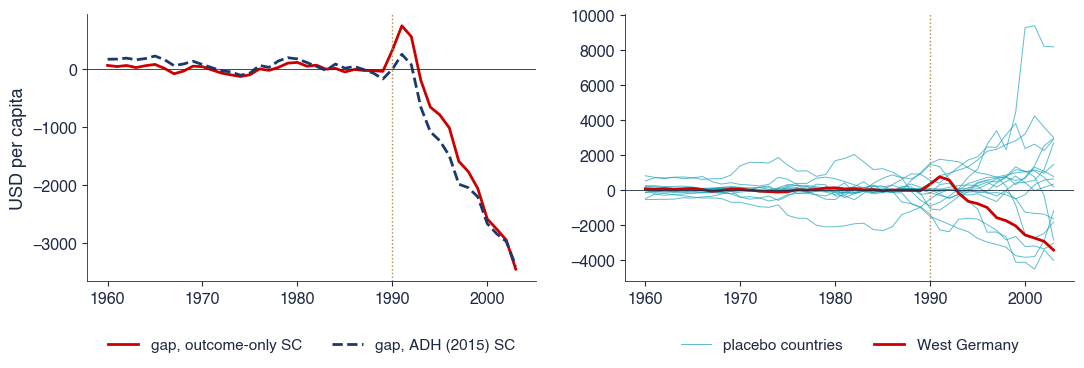

{'w': {'USA': 0.3426099609360077, 'Austria': 0.3231702153948103, 'France': 0.03854054454434998, 'Italy': 0.061250281090201246, 'Norway': 0.027730916079829464, 'Switzerland': 0.10788268942508063, 'Greece': 0.09881539252972076}, 'avg_oo': -1297.4750968569213, 'avg_adh': -1587.642751713591, 'rmspe_oo': 60.844352613568184, 'rmspe_adh': 120.97061476654953, 'p': 0.058823529411764705, 'rank': 1, 'n': 17}


In [18]:
# Solution
print(b3_germany_outcome_only(save_it=False))

**Interpretation of the result.** A better pre-fit with different donors; the sign and the significance are unchanged.

## B4 [Proposed]: robustness of the Romanian synthetic control

**Question.** Is the effect robust to the donor pool, to single donors and to a placebo date? Model: B3.

1. Three donor pools.
2. Leave-one-out.
3. A placebo treatment in July 2024.
4. Interpretation.

**Report:** three averages, a range, one placebo average, one sentence.

In [ ]:
# Your code here


## B5 [Solved]: CausalImpact for Romanian inflation

**Question.** Does a state space counterfactual from CEE inflation rates agree with the synthetic control?

1. Fit on January 2017 - June 2025 and simulate 500 paths.
2. The average effect and the main coefficients.
3. Comparison with Lecture 14.
4. Interpretation.

**Report:** one effect with interval, three coefficients, one sentence.

- 300 paths here.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


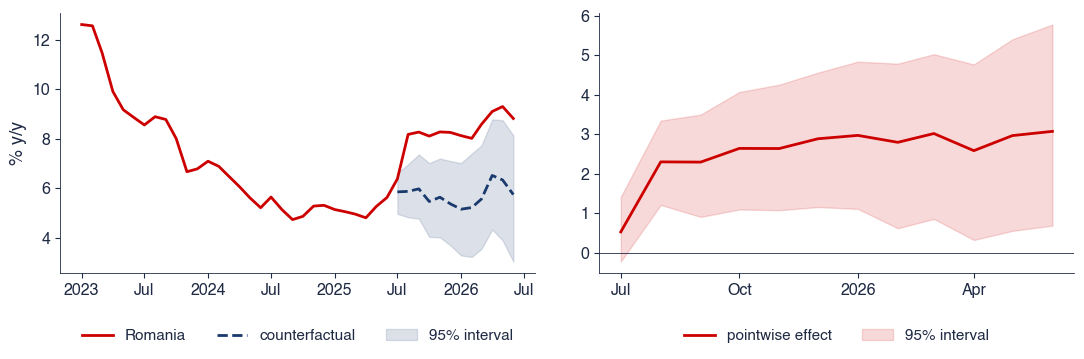

{'avg': 2.5563046977609147, 'lo': 0.8489049766907337, 'hi': 4.016540621468141, 'p': 0.0, 'beta': {'HU': -0.022021452181510085, 'PL': -0.059735962381893624, 'CZ': -0.06002909832267913, 'BG': 0.1951335882571718, 'HR': 0.4996762078126654, 'SK': 0.23932489495215992}, 's2l': 0.13441260276890565, 's2e': 3.8788635288081245e-15, 'n_pre': 102}


In [20]:
# Solution
print(b5_impact_romania(save_it=False, draws=300))

**Interpretation of the result.** Close to the synthetic control, with a wider interval; the stability of the controls is the doubtful assumption.

## B6 [Proposed]: placebo dates for the Bitcoin ETF analysis

**Question.** Would the CausalImpact model find effects where there are none? Model: B5.

1. Placebo dates April, July and October 2023.
2. The true date with the S&P 500 only.
3. Four effects with intervals.
4. Interpretation.

**Report:** four effects with intervals, one sentence.

In [ ]:
# Your code here


## B7 [Solved]: an interrupted time series with a placebo date

**Question.** Does the July 2025 effect survive dependent errors, and what does the same design find in July 2024?

1. The 12-month cumulative effect with i.i.d. and HAC standard errors.
2. The same with a placebo date in July 2024.
3. The z-statistics.
4. Interpretation.

**Report:** two effects, four standard errors, four z-statistics, one sentence.

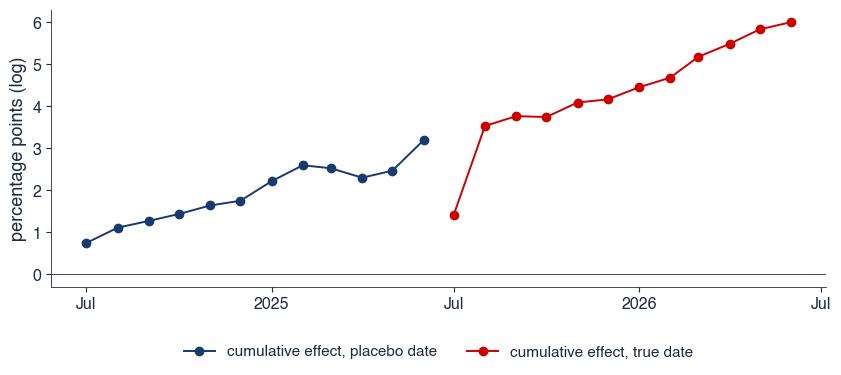

{'true': ({'cum': 6.0017697333115745, 'se': 1.5544782879612573, 'z': 3.86095436635726}, {'cum': 6.0017697333115745, 'se': 1.9818772557808044, 'z': 3.028325652259955}), 'placebo': ({'cum': 3.1909727668924672, 'se': 1.5903962950034554, 'z': 2.006401031565239}, {'cum': 3.1909727668924672, 'se': 1.992381578984989, 'z': 1.6015871661080583})}


In [22]:
# Solution
r = b7_its_placebo(save_it=False)
print({k: (v['iid'], v['hac']) for k, v in r.items()})

**Interpretation of the result.** The placebo is significant only with i.i.d. errors.

## B8 [Proposed]: PCMCI under different settings

**Question.** Which volatility links survive changes of tau_max and alpha? Model: B7.

1. Six runs.
2. The number of links of each run.
3. The links found in all runs.
4. Interpretation.

**Report:** six counts, a list of links, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: the Brexit doppelganger on revised data

**Question.** How fragile is the published Brexit output loss? Model: B3.

1. A five-line pre-registration.
2. Gaps in 2018Q4 and 2019Q4 with two donor pools.
3. Leave-one-out.
4. A project plan.

**Report:** a five-line plan, four gaps, a leave-one-out range, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) if x Granger-causes y, a policy that changes x will change y;
- (b) with 23 donors, a synthetic control placebo test can reach p = 0.01;
- (c) a perfect pre-treatment fit proves that the synthetic control is unbiased;
- (d) with AR(1) errors and rho = 0.5, i.i.d. standard errors of a long cumulative effect are too small by a factor of about 1.73;
- (e) CausalImpact is valid as long as the control series are correlated with the outcome;
- (f) convergent cross mapping cannot produce false positives because it uses nonlinear dynamics;
- (g) two-way fixed effects estimate the average effect on the treated under staggered adoption.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
